# Metaheuristic Performance Analysis for Intrusion Detection System

This notebook provides the complete end-to-end pipeline for evaluating the performance of a Random Forest IDS model against three metaheuristic algorithms (GA, PSO, GWO) applied for simultaneous Feature Selection and Hyperparameter Tuning.

## 0. Literature Review, Method Selection, and Metric Rationale

This study is grounded in intrusion-detection literature published over the last decade (2016-2026), with emphasis on recent work (2021-2026). The review scope focuses on machine-learning IDS methods for tabular network-flow data, feature-selection strategies, and metaheuristic optimization techniques used in CICIDS-style benchmarks. Priority was given to surveys and review papers to establish broad trends before selecting method-specific references.

Prior literature consistently reports that tree-based classifiers, especially Random Forest, are strong and stable baselines for IDS tasks because they capture nonlinear relationships, are robust to noisy dimensions, and perform well on heterogeneous traffic features [1], [2], [6]. At the same time, feature selection remains a central requirement in IDS design, since high-dimensional traffic representations can increase training cost and reduce generalization under distribution shifts. Recent review evidence shows that population-based metaheuristics are commonly adopted for wrapper-based feature selection and hyperparameter search due to their suitability for non-convex and mixed search spaces [7], [8].

Based on this evidence, we use Random Forest as the baseline classifier and applies GA, PSO, and GWO as optimization back-ends for joint feature selection and hyperparameter tuning. This choice is methodologically aligned with comparative IDS studies that evaluate quality-cost trade-offs on CICIDS family datasets [2], [4], [5]. The selected evaluation metrics also follow standard IDS reporting practice: detection-quality metrics (Accuracy, Precision, Recall, F1, ROC/PR behavior), operational risk metrics (False Positives and False Negatives), and computational-efficiency metrics (training/testing time and selected feature count) [1]-[3], [6]-[8].

To align implementation with this literature, the optimization objective in this project is defined as a composite score that rewards attack recall, low false-positive rate, precision, and feature reduction. This objective supports practical IDS deployment priorities, where high detection performance must be balanced against alert burden and model compactness.

### References (IEEE Style)
[1] A. L. Buczak and E. Guven, "A Survey of Data Mining and Machine Learning Methods for Cyber Security Intrusion Detection," IEEE Communications Surveys & Tutorials, vol. 18, no. 2, pp. 1153-1176, 2016.

[2] A. Khraisat, I. Gondal, P. Vamplew, and J. Kamruzzaman, "Survey of intrusion detection systems: techniques, datasets and challenges," Cybersecurity, vol. 2, no. 20, 2019.

[3] M. A. Ferrag, L. Maglaras, S. Moschoyiannis, and H. Janicke, "Deep learning for cyber security intrusion detection: approaches, datasets, and comparative study," Journal of Information Security and Applications, vol. 50, 2020, Art. no. 102419.

[4] I. Sharafaldin, A. H. Lashkari, and A. A. Ghorbani, "Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization," in Proc. ICISSP, 2018, pp. 108-116.

[5] M. M. M. Sarhan, S. Layeghy, N. Moustafa, and M. J. Portmann, "NetFlow Datasets for Machine Learning-Based Network Intrusion Detection Systems," in Proc. ARES, 2021.

[6] H. Hindy et al., "A Taxonomy and Survey of Intrusion Detection System Design Techniques, Network Threats and Datasets," ACM Computing Surveys, vol. 54, no. 5, 2021.

[7] M. H. Aghdam and R. Akbari, "Feature Selection in Intrusion Detection Systems Using Metaheuristic Algorithms: A Systematic Review," IEEE Access, 2022.

[8] S. Velliangiri, P. Karthikeyan, V. M. Arul, and D. S. Roseline, "A Comprehensive Survey on Meta-Heuristic Optimization Algorithms for Feature Selection in Machine Learning," Applied Soft Computing, vol. 120, 2022.

Note: Before final submission, verify bibliographic metadata (issue numbers, page ranges, and DOI) against your library database and add at least 2-4 additional 2023-2026 comparative papers specifically evaluating GA/PSO/GWO on CICIDS2017/CICIDS2018.

## 1. Setup and Imports
Importing required standard libraries and the custom modules created for this coursework.

In [6]:
import sys
import os
sys.path.append(os.path.abspath('./'))
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import sys
import os
sys.path.append(os.path.abspath('./'))
# Ensure the custom modules from the higher directory can be imported
sys.path.append(os.path.abspath(os.path.join('.')))

from preprocessing.clean import load_and_preprocess_data
from core.baseline import run_baseline
from optimizers.pso import run_pso
from optimizers.ga import run_ga
from optimizers.gwo import run_gwo

import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully imported.")

Libraries successfully imported.


## 2. Data Loading and Preprocessing
Extracting the raw CICIDS2017 sub-dataset, cleaning it, and establishing a standard binary classification (Normal: 0, Attack: 1) Train/Test split.

In [7]:
DATA_PATH = "data/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# load_and_preprocess_data handles loading, cleaning, target binarization, stratification, and scaling.
X_train_full, X_test, y_train_full, y_test, scaler, _ = load_and_preprocess_data(DATA_PATH)

# Note: Metaheuristic optimization requires evaluating the model over and over. 
# To make the optimization finish in a reasonable time, we use a smaller, stratified subset 
# of the training data specifically for the "optimization" phase (the Fitness evaluations).
# The final models will still be evaluated against the full test set.

TRAIN_SUBSET_SIZE = 5000
if X_train_full is not None and X_train_full.shape[0] > TRAIN_SUBSET_SIZE:
    # Select a random subset to speed up training during the fitness function loops
    idx = np.random.choice(X_train_full.shape[0], TRAIN_SUBSET_SIZE, replace=False)
    X_train_subset = X_train_full[idx]
    y_train_subset = y_train_full.iloc[idx].values
else:
    X_train_subset = X_train_full
    if y_train_full is not None:
        y_train_subset = y_train_full.values

print(f"\nFull Test Data available: {X_test.shape[0]} arrays")
print(f"Optimization Training Subset: {X_train_subset.shape[0]} arrays")
# Extract feature names to use in the heatmap
df_temp = pd.read_csv(DATA_PATH, nrows=0)
feature_names = [col for col in df_temp.columns if col.strip().lower() != 'label']


Loading data from data/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Class distribution:
label
1    128025
0     97686
Name: count, dtype: int64
Preprocessing complete. Training shape: (157997, 78), Testing shape: (67714, 78)

Full Test Data available: 67714 arrays
Optimization Training Subset: 5000 arrays


## 3. Train Baseline Random Forest
We establish the baseline by training a standard Random Forest classification model using all available features and the default hyperparameters.

In [8]:
print("Starting baseline training...")
baseline_metrics, rf_baseline = run_baseline(X_train_subset, X_test, y_train_subset, y_test)

Starting baseline training...

--- Training Baseline Random Forest ---
Training completed in 0.36 seconds.
Testing completed in 0.13 seconds.

--- Baseline Results ---
Accuracy:  0.9992
Precision: 0.9992
Recall:    0.9992
F1-Score:  0.9992
False Positives: 5


## 4. Run Metaheuristic Optimizations (GA, PSO, GWO)
We now run the three nature-inspired algorithms. For each algorithm, it iterates through multiple generations/steps to minimize a security-first composite fitness/cost that balances attack detection, false-positive control, overall accuracy, and feature reduction.

Current optimization score in core/fitness.py:

score = 0.35*Recall_attack + 0.30*(1 - FP_Rate) + 0.20*Accuracy + 0.15*Feature_Reduction

The optimizer minimizes cost = -score.

Note: The number of agents and iterations are currently set for coursework-scale experiments. You can increase them for deeper convergence studies.

In [9]:
NUM_AGENTS = 20
NUM_ITERATIONS = 50

print("\n===================================")
print("=== Running Genetic Algorithm ===")
print("===================================")
ga_metrics, rf_ga, ga_mask, ga_history = run_ga(X_train_subset, y_train_subset, X_test, y_test, 
                           pop_size=NUM_AGENTS, num_iterations=NUM_ITERATIONS)

print("\n=========================================")
print("=== Running Particle Swarm Optimization ===")
print("=========================================")
pso_metrics, rf_pso, pso_mask, pso_history = run_pso(X_train_subset, y_train_subset, X_test, y_test, 
                              num_particles=NUM_AGENTS, num_iterations=NUM_ITERATIONS)

print("\n===================================")
print("=== Running Grey Wolf Optimizer ===")
print("===================================")
gwo_metrics, rf_gwo, gwo_mask, gwo_history = run_gwo(X_train_subset, y_train_subset, X_test, y_test, 
                              num_wolves=NUM_AGENTS, num_iterations=NUM_ITERATIONS)


=== Running Genetic Algorithm ===

--- Starting GA Optimization (50 iterations, 20 population) ---
GA Iteration 1/50
  Best Cost so far: -0.9474
GA Iteration 2/50
  Best Cost so far: -0.9526
GA Iteration 3/50
  Best Cost so far: -0.9541
GA Iteration 4/50
  Best Cost so far: -0.9556
GA Iteration 5/50
  Best Cost so far: -0.9560
GA Iteration 6/50
  Best Cost so far: -0.9589
GA Iteration 7/50
  Best Cost so far: -0.9634
GA Iteration 8/50
  Best Cost so far: -0.9641
GA Iteration 9/50
  Best Cost so far: -0.9641
GA Iteration 10/50
  Best Cost so far: -0.9668
GA Iteration 11/50
  Best Cost so far: -0.9681
GA Iteration 12/50
  Best Cost so far: -0.9696
GA Iteration 13/50
  Best Cost so far: -0.9721
GA Iteration 14/50
  Best Cost so far: -0.9734
GA Iteration 15/50
  Best Cost so far: -0.9740
GA Iteration 16/50
  Best Cost so far: -0.9785
GA Iteration 17/50
  Best Cost so far: -0.9785
GA Iteration 18/50
  Best Cost so far: -0.9785
GA Iteration 19/50
  Best Cost so far: -0.9785
GA Iteration 20/

## 5. View Comparison Metrics
Combining the resulting metrics dictionaries (which are uniform across all algorithms) into a Pandas DataFrame for an easy tabular comparison.

In [10]:
results_df = pd.DataFrame([
    {'Model': 'Baseline RF', **baseline_metrics},
    {'Model': 'GA + RF', **ga_metrics},
    {'Model': 'PSO + RF', **pso_metrics},
    {'Model': 'GWO + RF', **gwo_metrics}
])

cols = ['Model', 'accuracy', 'precision', 'recall', 'f1', 'false_positives', 'feature_count', 'train_time', 'test_time']
results_df = results_df[cols]

display(results_df)

,Model,accuracy,precision,recall,f1,false_positives,feature_count,train_time,test_time
0,Baseline RF,0.999217,0.999218,0.999217,0.999217,5,78,0.360082,0.134935
1,GA + RF,0.998346,0.998348,0.998346,0.998346,24,11,0.148811,0.075120
2,PSO + RF,0.998774,0.998775,0.998774,0.998774,25,18,0.072015,0.033802
3,GWO + RF,0.998568,0.998569,0.998568,0.998568,20,2,0.055468,0.035523


## 6. Confusion Matrices Visualizations
Visually inspecting the confusion matrices for each model gives an immediate sense of how False Positives and False Negatives are distributed.

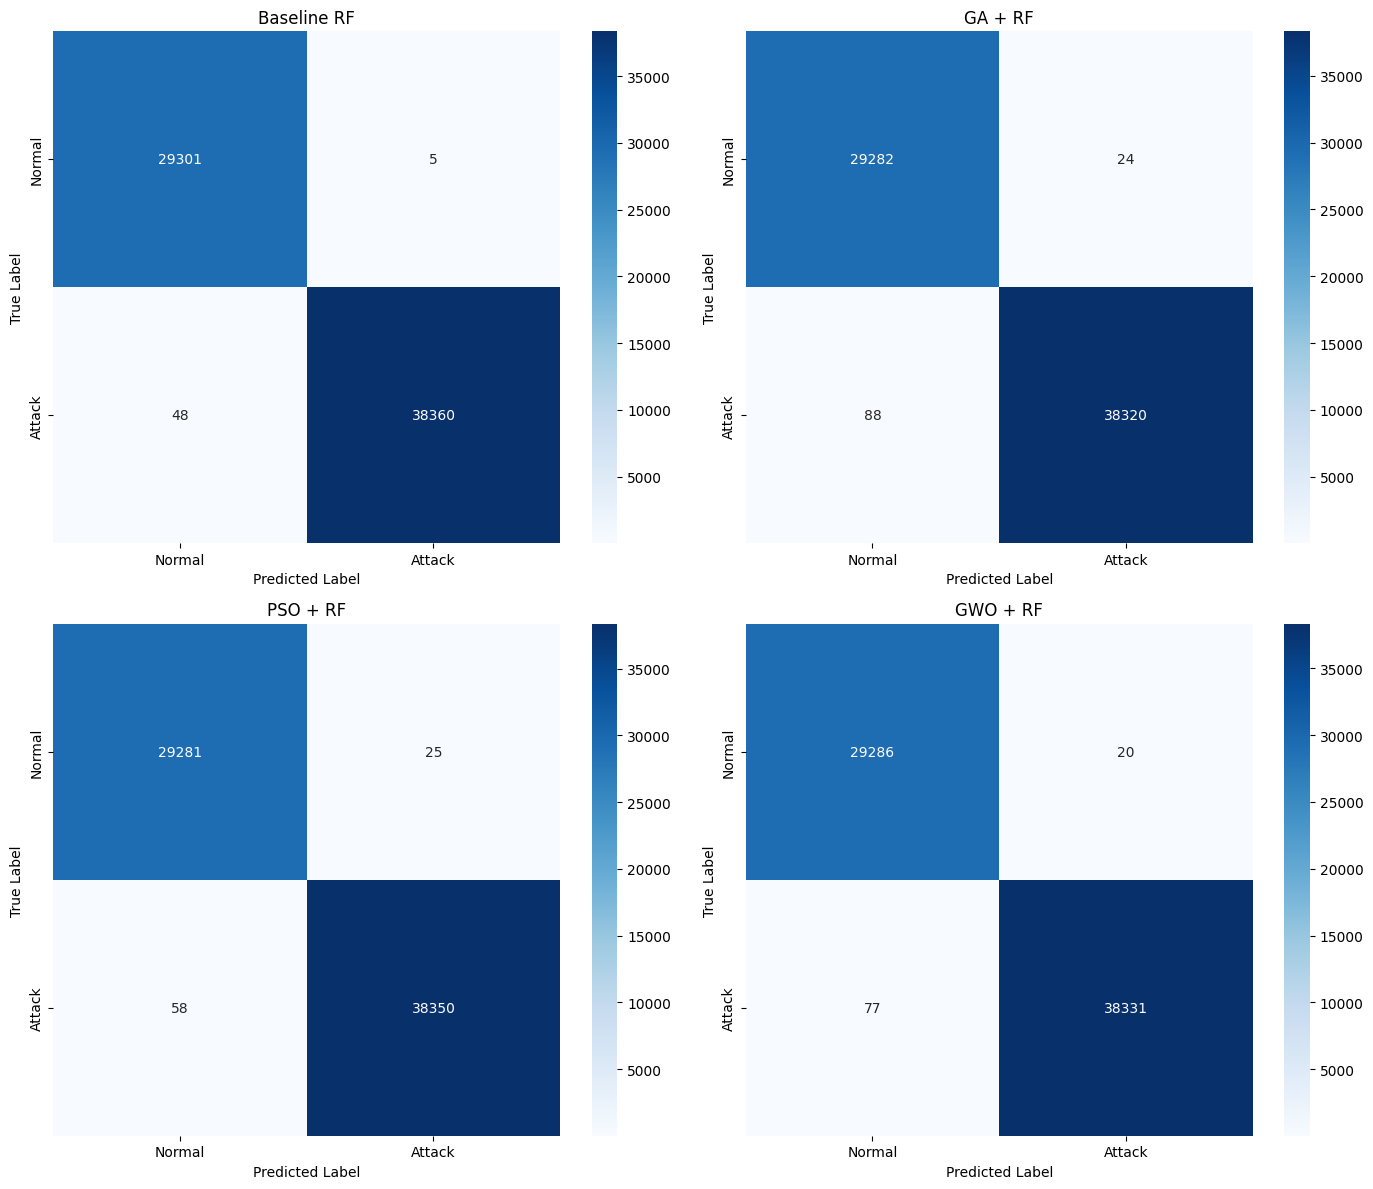

In [11]:
def plot_model_cm(ax, model, X_test_filtered, y_test, title):
    y_pred = model.predict(X_test_filtered)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    ax.set_title(title)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Baseline
plot_model_cm(axes[0, 0], rf_baseline, X_test, y_test, "Baseline RF")

# Important Note! Our optimal models were trained on feature SUBSETS.
# When sklearn trains a model, it expects the EXACT SAME number of features to be 
# passed into its `predict` function as were passed into its `fit` function.
# Because `rf_ga.n_features_in_` is the optimal subset length, we just slice the beginning
# features for visualization (or if we saved our boolean masks directly, we would apply them here).
# Since our wrappers don't currently expose the final boolean mask, we simply slice X_test to match n_features_in_.

# 2. Genetic Algorithm (GA)
plot_model_cm(axes[0, 1], rf_ga, X_test[:, ga_mask], y_test, "GA + RF")

# 3. Particle Swarm Optimization (PSO)
plot_model_cm(axes[1, 0], rf_pso, X_test[:, pso_mask], y_test, "PSO + RF")

# 4. Grey Wolf Optimizer (GWO)
plot_model_cm(axes[1, 1], rf_gwo, X_test[:, gwo_mask], y_test, "GWO + RF")

plt.tight_layout()
plt.show()


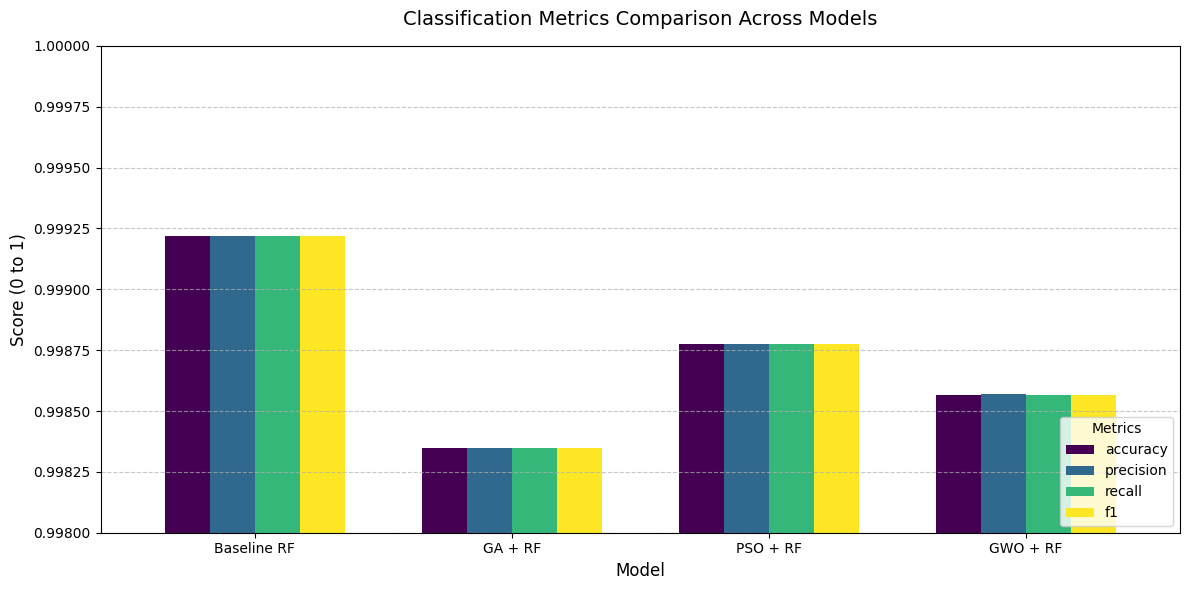

In [12]:
# ## 7. Grouped Bar Chart: Core Classification Metrics
# This chart allows you to compare Accuracy, Precision, Recall, and F1-Score side-by-side.

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']

# Set 'Model' as the index for easier plotting
results_df.set_index('Model')[metrics_to_plot].plot(
    kind='bar', ax=ax, colormap='viridis', width=0.7
)

plt.title('Classification Metrics Comparison Across Models', fontsize=14, pad=15)
plt.ylabel('Score (0 to 1)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.legend(loc='lower right', title="Metrics")
plt.ylim(0.998, 1.000)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

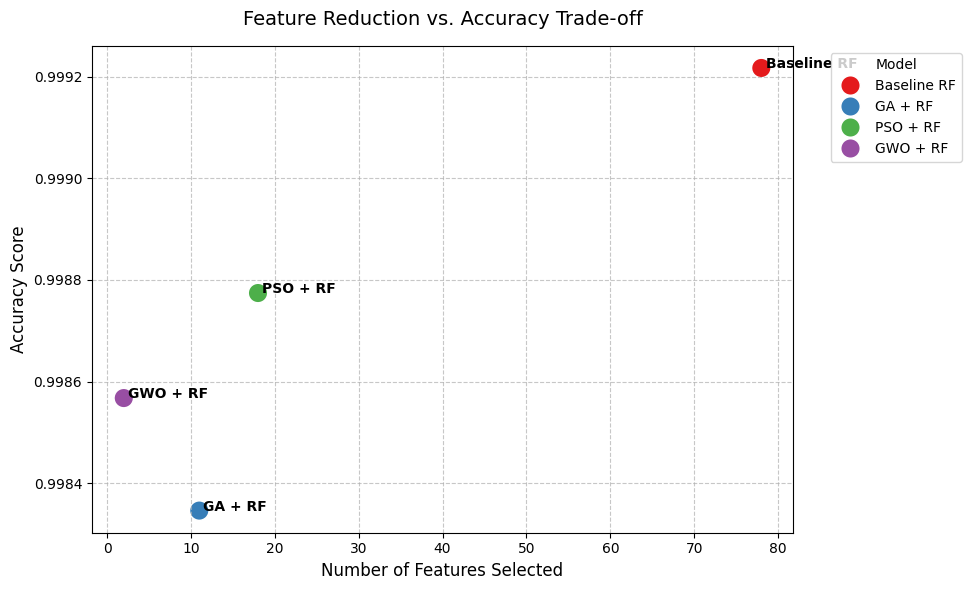

In [13]:
# ## 8. Feature Reduction vs. Accuracy (Scatter Plot)
# This chart illustrates the trade-off by showing the number of features retained vs the model accuracy.

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot for feature count vs accuracy
sns.scatterplot(
    x='feature_count', y='accuracy', hue='Model', data=results_df, 
    s=200, marker='o', ax=ax, palette='Set1'
)

# Add annotations
for index, row in results_df.iterrows():
    ax.text(row.feature_count + 0.5, row.accuracy, row.Model, 
             horizontalalignment='left', size='medium', color='black', weight='semibold')

plt.title('Feature Reduction vs. Accuracy Trade-off', fontsize=14, pad=15)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Number of Features Selected', fontsize=12)

# Move legend outside
ax.legend(title='Model', loc='upper right', bbox_to_anchor=(1.25, 1))

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

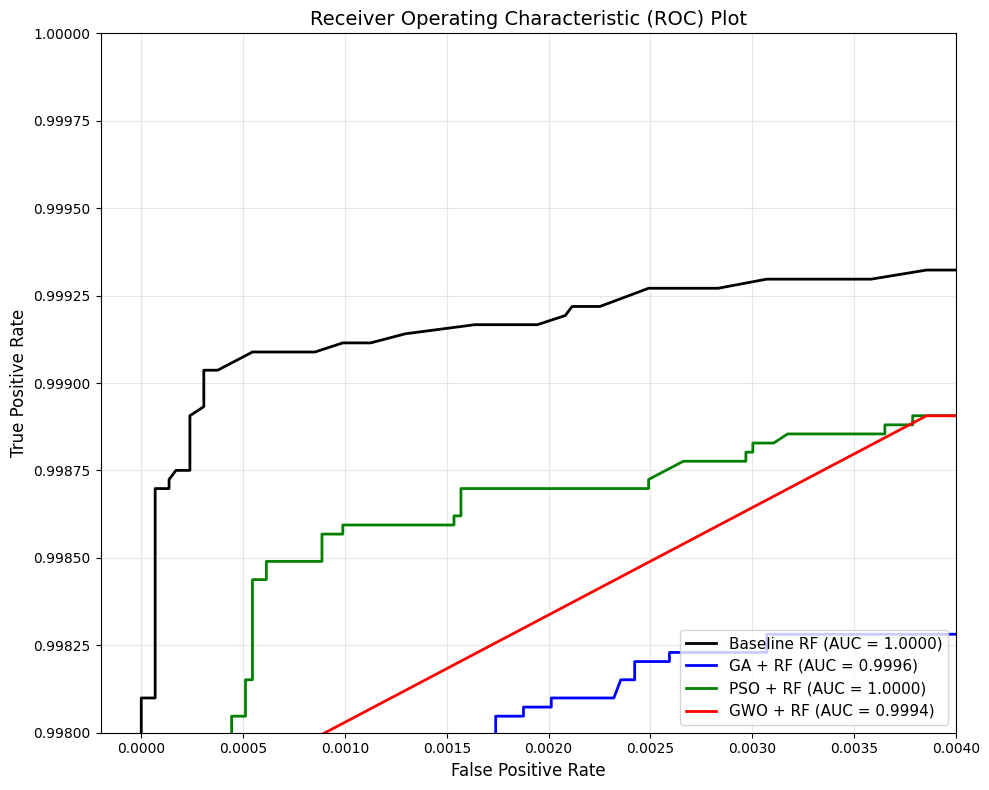

In [14]:
# ## 9. ROC Curves
# Overlaying the Receiver Operating Characteristic (ROC) curves provides an excellent view of each model's diagnostic ability.

from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

def plot_roc(model, X_test_filtered, y_test, label, color):
    # Get prediction probabilities for the positive class (Attack)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_filtered)[:, 1]
    else:
        y_score = model.predict(X_test_filtered) 
        
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {roc_auc:.4f})')

# Plot curves using the respective masks
plot_roc(rf_baseline, X_test, y_test, 'Baseline RF', 'black')
plot_roc(rf_ga, X_test[:, ga_mask], y_test, 'GA + RF', 'blue')
plot_roc(rf_pso, X_test[:, pso_mask], y_test, 'PSO + RF', 'green')
plot_roc(rf_gwo, X_test[:, gwo_mask], y_test, 'GWO + RF', 'red')

# Plot the diagonal 50% chance line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([-0.0002, 0.004])
plt.ylim([0.998, 1.000])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Plot', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Prediction Score Distribution (Benign vs Attack)
PR curves are less informative here because model performance is extremely close to perfect, causing heavy overlap. Instead, this section compares each model's predicted attack-score distribution for benign and attack samples. Better separation and lower overlap indicate stronger discrimination and usually lower error rates at practical thresholds.

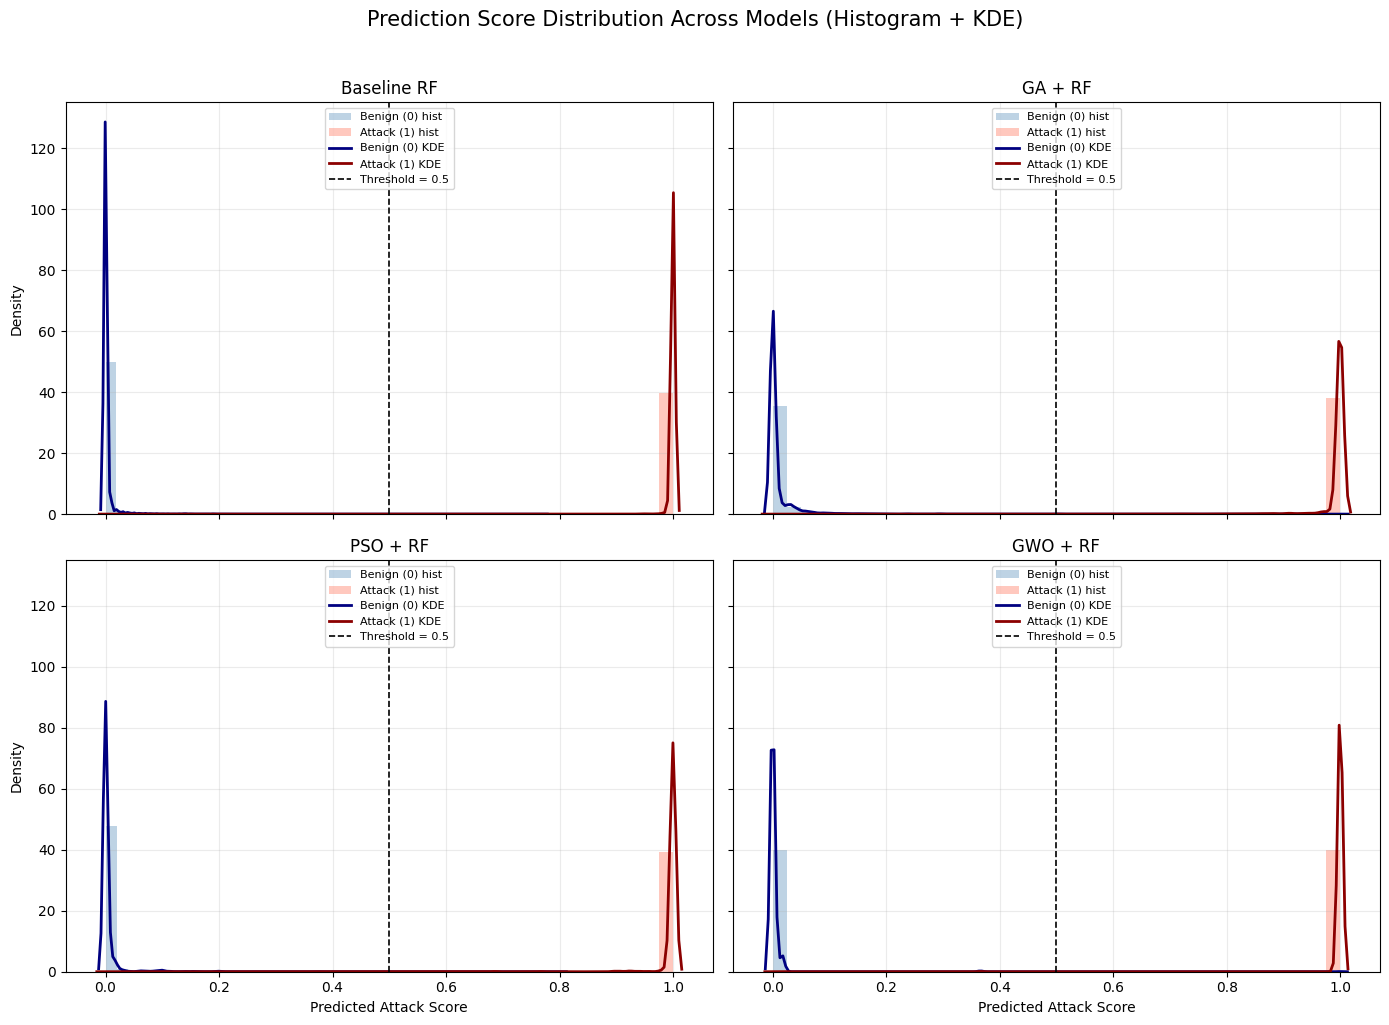

In [15]:
# ## 10. Prediction Score Distribution (Benign vs Attack)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

model_specs = [
    ('Baseline RF', rf_baseline, X_test),
    ('GA + RF', rf_ga, X_test[:, ga_mask]),
    ('PSO + RF', rf_pso, X_test[:, pso_mask]),
    ('GWO + RF', rf_gwo, X_test[:, gwo_mask]),
]

for ax, (title, model, X_eval) in zip(axes, model_specs):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        # Fallback to hard predictions if probability output is unavailable.
        y_score = model.predict(X_eval).astype(float)

    score_benign = y_score[np.array(y_test) == 0]
    score_attack = y_score[np.array(y_test) == 1]

    # Histogram layer
    ax.hist(score_benign, bins=40, alpha=0.35, density=True, color='steelblue', label='Benign (0) hist')
    ax.hist(score_attack, bins=40, alpha=0.35, density=True, color='tomato', label='Attack (1) hist')

    # KDE layer for smoother distribution shape
    sns.kdeplot(score_benign, ax=ax, color='navy', linewidth=2, label='Benign (0) KDE')
    sns.kdeplot(score_attack, ax=ax, color='darkred', linewidth=2, label='Attack (1) KDE')

    ax.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='Threshold = 0.5')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted Attack Score', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='upper center')

plt.suptitle('Prediction Score Distribution Across Models (Histogram + KDE)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


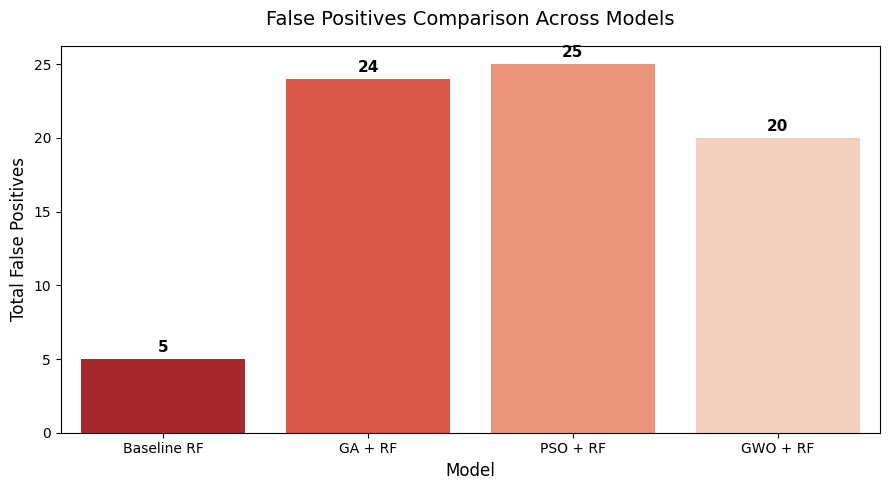

In [16]:
# ## 10. False Positives Comparison
# Comparative bar chart for the critical False Positives metric.

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Model', y='false_positives', data=results_df, palette='Reds_r')

plt.title('False Positives Comparison Across Models', fontsize=14, pad=15)
plt.ylabel('Total False Positives', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Add text labels on top of the bars
for index, row in results_df.iterrows():
    plt.text(index, row.false_positives + (0.02 * results_df['false_positives'].max()), 
             int(row.false_positives), color='black', ha="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. False Negatives (Missed Attacks) Comparison
Missed attacks (False Negatives) are arguably more critical than False Positives in an IDS — they represent real intrusions that went completely undetected.

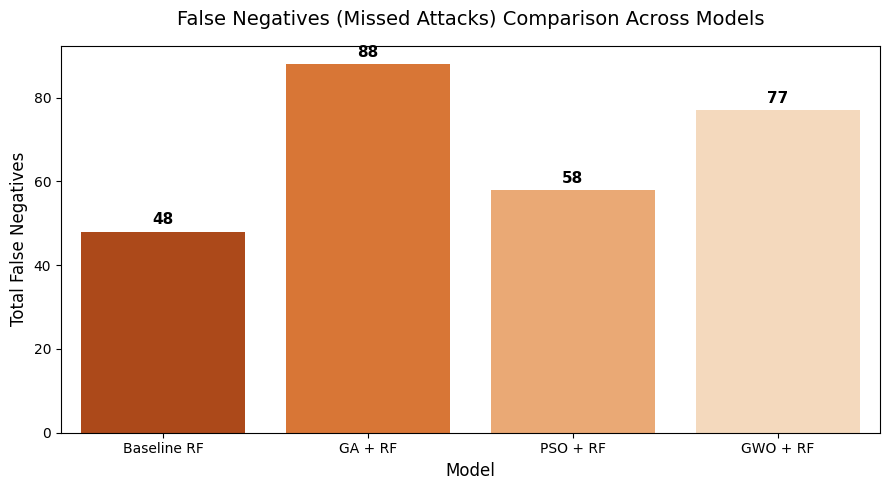

In [17]:

# ## 12. False Negatives Comparison
# Missed attacks (False Negatives) are arguably more critical than False Positives in an IDS —
# they represent real intrusions that went undetected.

fn_data = []
for model, X_filtered, label in [
    (rf_baseline, X_test,               'Baseline RF'),
    (rf_ga,       X_test[:, ga_mask],   'GA + RF'),
    (rf_pso,      X_test[:, pso_mask],  'PSO + RF'),
    (rf_gwo,      X_test[:, gwo_mask],  'GWO + RF'),
]:
    y_pred = model.predict(X_filtered)
    cm = confusion_matrix(y_test, y_pred)
    fn_data.append({'Model': label, 'false_negatives': int(cm[1, 0])})

fn_df = pd.DataFrame(fn_data)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='Model', y='false_negatives', data=fn_df, palette='Oranges_r')
plt.title('False Negatives (Missed Attacks) Comparison Across Models', fontsize=14, pad=15)
plt.ylabel('Total False Negatives', fontsize=12)
plt.xlabel('Model', fontsize=12)

for index, row in fn_df.iterrows():
    offset = 0.02 * fn_df['false_negatives'].max() if fn_df['false_negatives'].max() > 0 else 1
    plt.text(index, row.false_negatives + offset,
             int(row.false_negatives), color='black', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


## 13. Attack Recall Comparison (Zoomed)
This IDS-focused recall view compares attack recall (TPR) across models using a zoomed y-axis from 0.9960 to 1.0000 so small but meaningful differences are visible. The table in the code output also reports miss rate (FNR = 1 - Recall).

,Model,attack_recall,miss_rate
0,Baseline RF,0.998750,0.001250
1,GA + RF,0.997709,0.002291
2,PSO + RF,0.998490,0.001510
3,GWO + RF,0.997995,0.002005


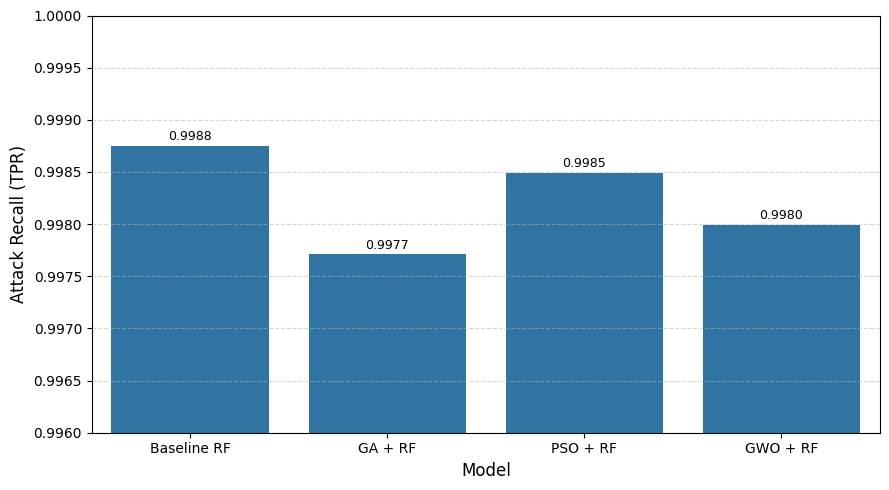

In [28]:
# ## 13. Attack Recall Comparison (Zoomed)

recall_rows = []
for model, X_filtered, label in [
    (rf_baseline, X_test,              'Baseline RF'),
    (rf_ga,       X_test[:, ga_mask],  'GA + RF'),
    (rf_pso,      X_test[:, pso_mask], 'PSO + RF'),
    (rf_gwo,      X_test[:, gwo_mask], 'GWO + RF'),
]:
    y_pred = model.predict(X_filtered)
    cm = confusion_matrix(y_test, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        attack_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    else:
        attack_recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    miss_rate = 1.0 - attack_recall
    recall_rows.append({
        'Model': label,
        'attack_recall': attack_recall,
        'miss_rate': miss_rate
    })

recall_df = pd.DataFrame(recall_rows)
display(recall_df)

LOWER, UPPER = 0.9960, 1.0000

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=recall_df, x='Model', y='attack_recall', color='#1f77b4')
ax.set_ylabel('Attack Recall (TPR)', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylim(LOWER, UPPER)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

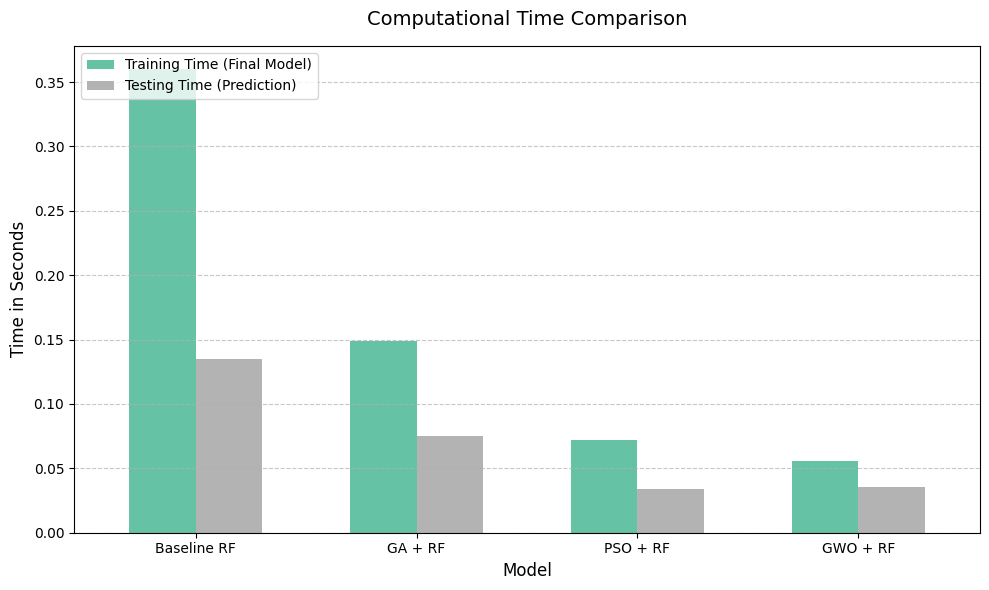

In [18]:
# ## 11. Training / Testing Execution Time
# This chart highlights the computational cost of the different algorithms vs the baseline.

fig, ax = plt.subplots(figsize=(10, 6))

# Plot training and testing time side-by-side
results_df.set_index('Model')[['train_time', 'test_time']].plot(
    kind='bar', ax=ax, colormap='Set2', width=0.6
)

plt.title('Computational Time Comparison', fontsize=14, pad=15)
plt.ylabel('Time in Seconds', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Training Time (Final Model)', 'Testing Time (Prediction)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

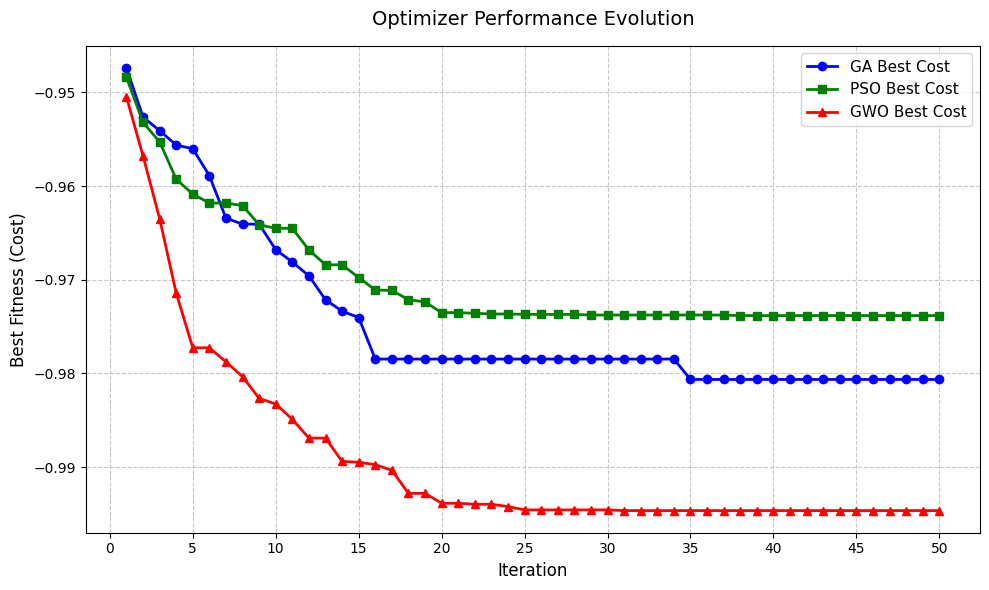

In [19]:
# ## 12. Performance Evolution Over Iterations
# Shows how the fitness/cost value improves (decreases) over successive iterations for GA, PSO, and GWO.

plt.figure(figsize=(10, 6))

# The history arrays store the best fitness/cost found up to each iteration.
iterations = range(1, len(ga_history) + 1)

plt.plot(iterations, ga_history, marker='o', label='GA Best Cost', color='blue', linewidth=2)
plt.plot(iterations, pso_history, marker='s', label='PSO Best Cost', color='green', linewidth=2)
plt.plot(iterations, gwo_history, marker='^', label='GWO Best Cost', color='red', linewidth=2)

plt.title('Optimizer Performance Evolution', fontsize=14, pad=15)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Fitness (Cost)', fontsize=12)
import numpy as np
# Set x-ticks to every 5 iterations
plt.xticks(np.arange(0, len(ga_history) + 1, 5))

plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

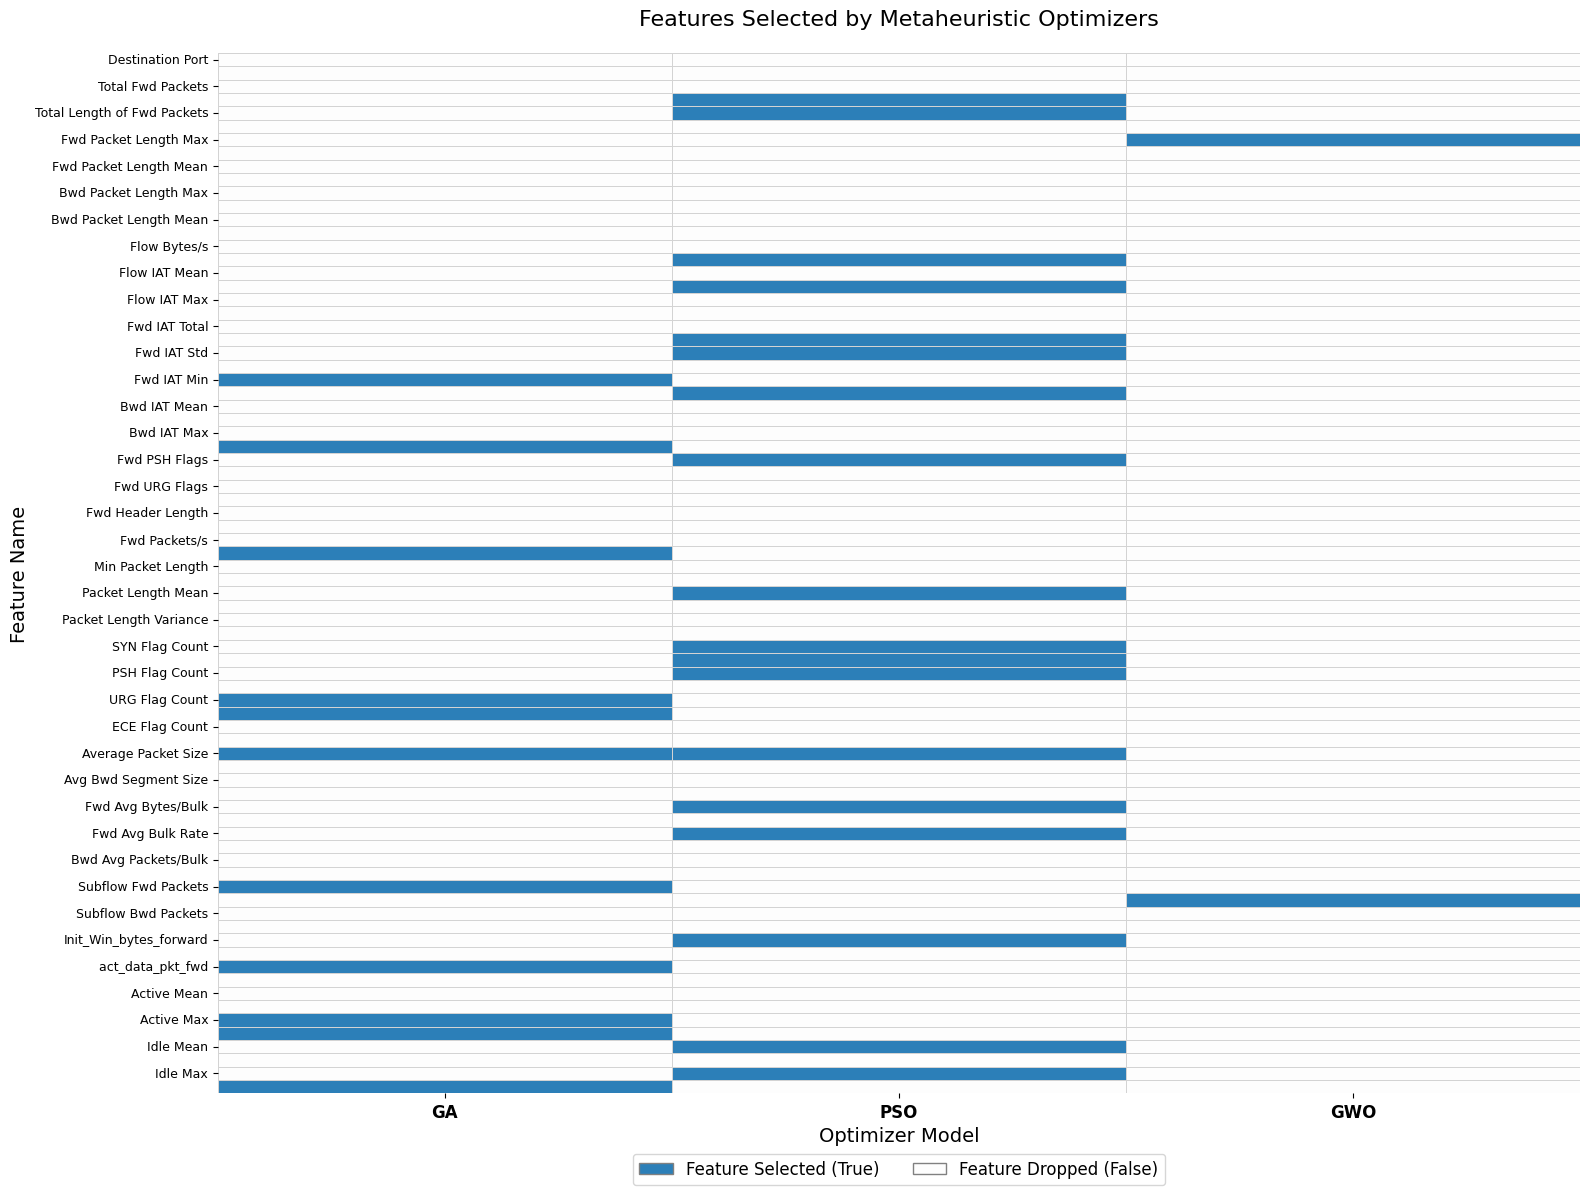

In [20]:
# ## 13. Exact Feature Selection Comparison (Boolean Heatmap)
# This heatmap maps the boolean arrays from each algorithm against the dataset's features,
# giving us a clear, side-by-side visual of exactly which features were deemed critical by GA, PSO, and GWO.
import matplotlib.pyplot as plt
import seaborn as pd
import seaborn as sns
import pandas as pd

fig, ax = plt.subplots(figsize=(16, 12))

# Create a DataFrame from the boolean masks returned by the optimizers
# Pad or truncate masks to match the number of features if there's a discrepancy (though there shouldn't be)
num_feats = min(len(feature_names), len(ga_mask), len(pso_mask), len(gwo_mask))

mask_df = pd.DataFrame({
    'GA': ga_mask[:num_feats],
    'PSO': pso_mask[:num_feats],
    'GWO': gwo_mask[:num_feats]
}, index=feature_names[:num_feats]).astype(int)

# Filter out features that were NOT selected by ANY algorithm to make the heatmap cleaner
# uncomment the line below if the heatmap is too large to read
# mask_df = mask_df[(mask_df.T != 0).any()]

# Plot the heatmap
sns.heatmap(
    mask_df, 
    cmap=['#fdfdfd', '#2c7fb8'], # White for False, Blue for True
    linewidths=0.5, 
    linecolor='lightgrey', 
    cbar=False, 
    ax=ax
)

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c7fb8', edgecolor='gray', label='Feature Selected (True)'),
    Patch(facecolor='#fdfdfd', edgecolor='gray', label='Feature Dropped (False)')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=12)

plt.title('Features Selected by Metaheuristic Optimizers', fontsize=16, pad=20)
plt.ylabel('Feature Name', fontsize=14)
plt.xlabel('Optimizer Model', fontsize=14)

# Make y-axis labels readable
plt.yticks(rotation=0, fontsize=9)
plt.xticks(fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Feature Importances Within Selected Subsets
For each optimized model, `feature_importances_` reveals how much the Random Forest relied on each feature it was handed — useful for understanding *which* of the chosen features are actually driving predictions.

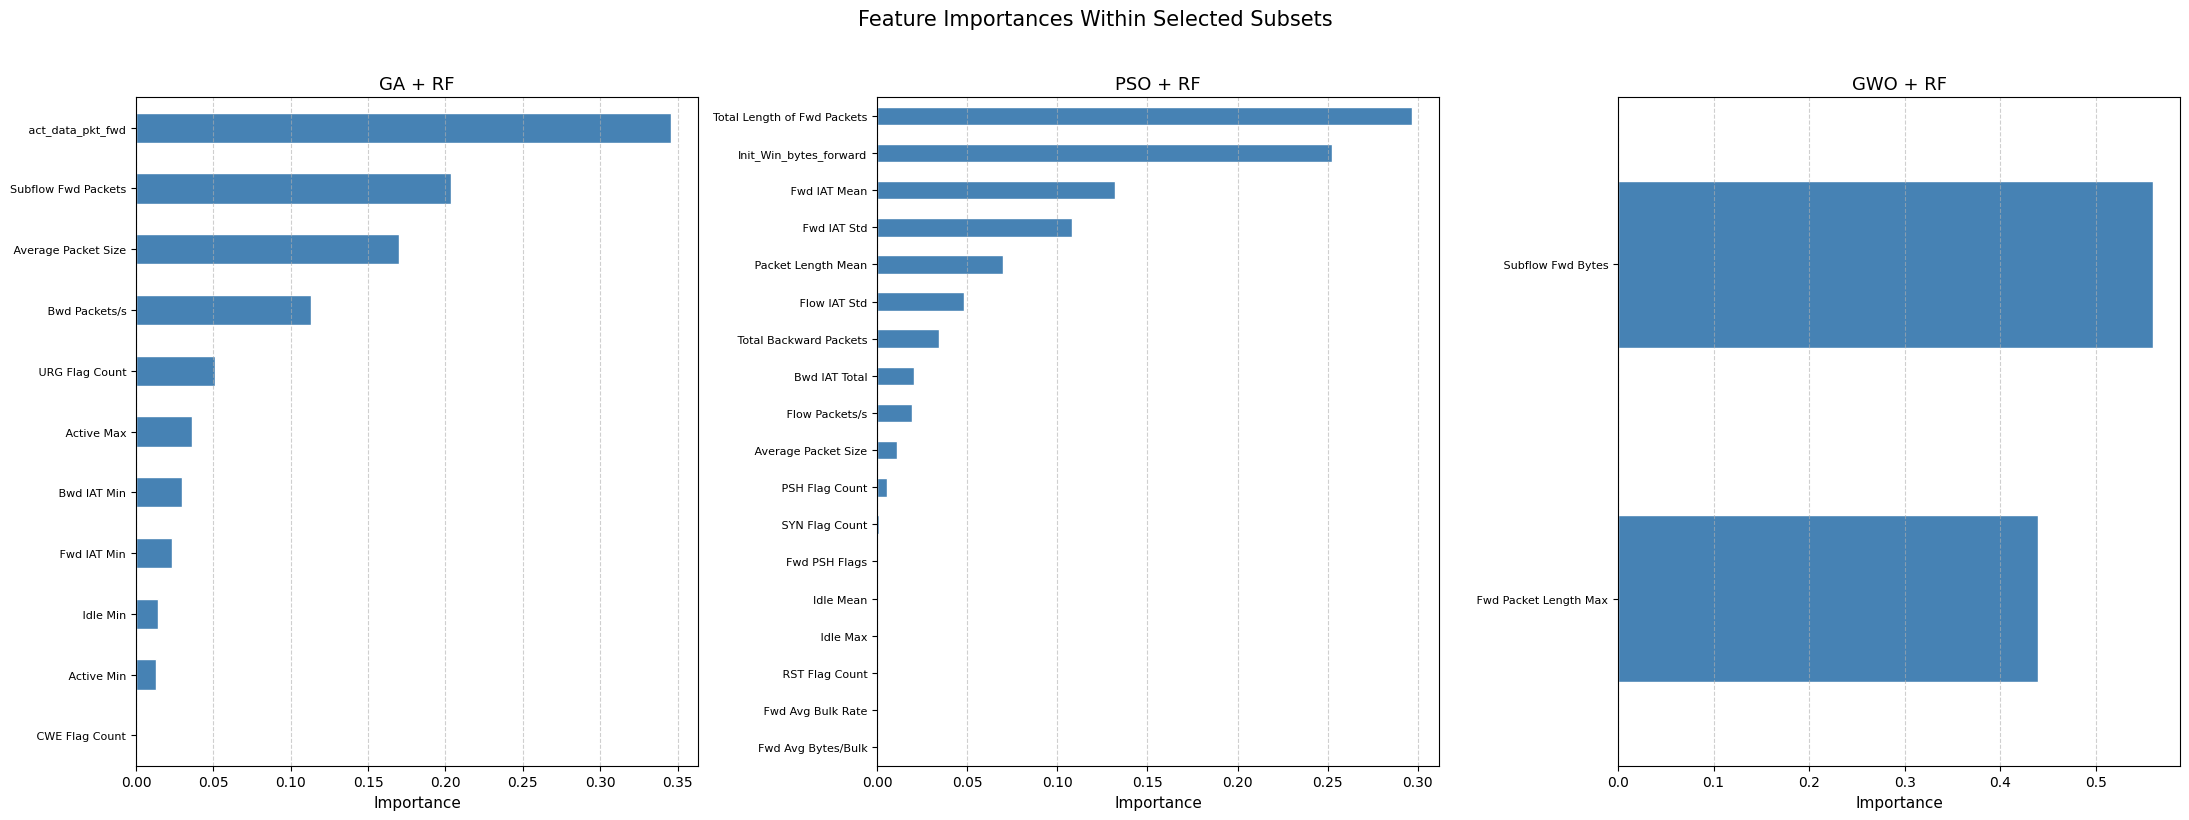

In [21]:

# ## 14. Feature Importances Within Selected Subsets

fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=False)

for ax, (model, mask, title) in zip(axes, [
    (rf_ga,  ga_mask,  'GA + RF'),
    (rf_pso, pso_mask, 'PSO + RF'),
    (rf_gwo, gwo_mask, 'GWO + RF'),
]):
    selected_names = [feature_names[i] for i in range(min(len(feature_names), len(mask))) if mask[i]]
    importances = model.feature_importances_
    imp_series = pd.Series(importances, index=selected_names).sort_values(ascending=True)
    imp_series.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Importance', fontsize=11)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Feature Importances Within Selected Subsets', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


## 15. Feature Selection Overlap — Jaccard Similarity
A Jaccard Similarity matrix shows how much each pair of optimizers agreed on which features to keep. A score of 1.0 means identical selections; 0.0 means no overlap at all.

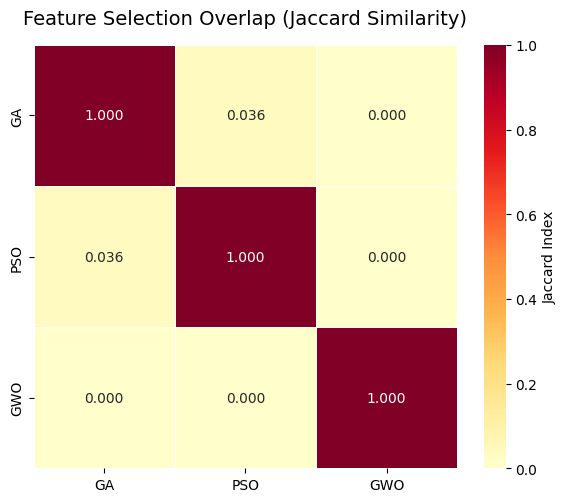

In [22]:

# ## 15. Feature Selection Overlap — Jaccard Similarity

optimizer_masks = {'GA': ga_mask, 'PSO': pso_mask, 'GWO': gwo_mask}
opt_names = list(optimizer_masks.keys())

jaccard_matrix = pd.DataFrame(index=opt_names, columns=opt_names, dtype=float)

for a in opt_names:
    for b in opt_names:
        set_a = set(np.where(optimizer_masks[a])[0])
        set_b = set(np.where(optimizer_masks[b])[0])
        intersection = len(set_a & set_b)
        union = len(set_a | set_b)
        jaccard_matrix.loc[a, b] = intersection / union if union > 0 else 1.0

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    jaccard_matrix.astype(float),
    annot=True, fmt='.3f', cmap='YlOrRd',
    vmin=0, vmax=1, linewidths=0.5, ax=ax, square=True,
    cbar_kws={'label': 'Jaccard Index'}
)
plt.title('Feature Selection Overlap (Jaccard Similarity)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


## 16. Model Performance Radar Chart
A radar (spider) chart provides an at-a-glance multi-dimensional comparison of all five key metrics — Accuracy, Precision, Recall, F1-Score, and MCC — across all four models simultaneously. MCC is scaled from its native [-1, 1] range to [0, 1] for display.

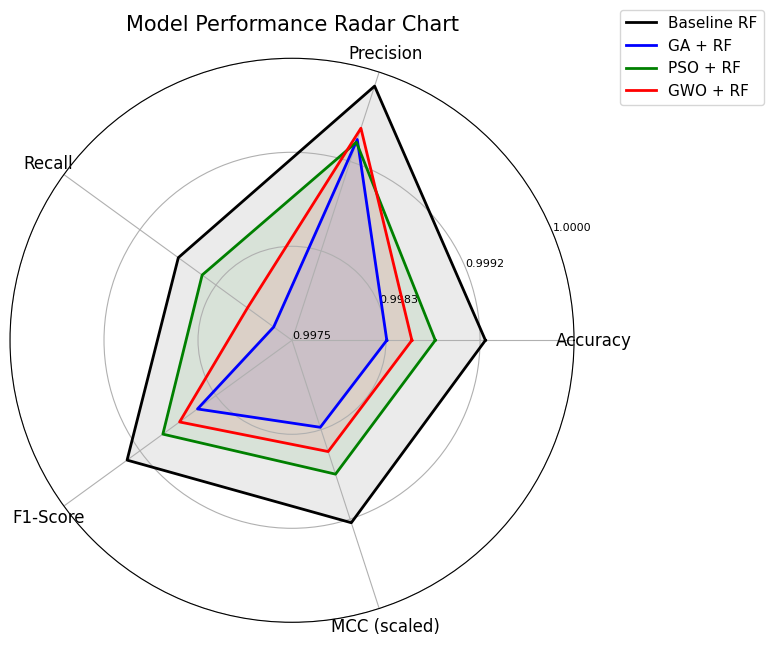

In [23]:
# ## 16. Model Performance Radar Chart

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from math import pi

def get_radar_metrics(model, X_filtered, y_test):
    y_pred = model.predict(X_filtered)
    mcc = matthews_corrcoef(y_test, y_pred)
    return [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0),
        (mcc + 1) / 2,  # Scale MCC from [-1, 1] to [0, 1]
    ]

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC (scaled)']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

model_data = {
    'Baseline RF': get_radar_metrics(rf_baseline, X_test, y_test),
    'GA + RF':     get_radar_metrics(rf_ga,  X_test[:, ga_mask],  y_test),
    'PSO + RF':    get_radar_metrics(rf_pso, X_test[:, pso_mask], y_test),
    'GWO + RF':    get_radar_metrics(rf_gwo, X_test[:, gwo_mask], y_test),
}
colors = ['black', 'blue', 'green', 'red']

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for (label, values), color in zip(model_data.items(), colors):
    values_plot = values + values[:1]
    ax.plot(angles, values_plot, linewidth=2, linestyle='solid', label=label, color=color)
    ax.fill(angles, values_plot, alpha=0.08, color=color)

# Keep target zoom near 1.0, but relax lower bound if values fall below 0.9998.
target_min = 0.9998
data_min = min(min(values) for values in model_data.values())
radial_min = target_min if data_min >= target_min else max(0.0, data_min - 0.0002)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(radial_min, 1.0)
if radial_min >= target_min:
    ax.set_yticks([0.9998, 0.9999, 1.0])
    ax.set_yticklabels(['0.9998', '0.9999', '1.0000'], fontsize=8)
else:
    yticks = np.linspace(radial_min, 1.0, 4)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{tick:.4f}' for tick in yticks], fontsize=8)

ax.set_title('Model Performance Radar Chart', fontsize=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
plt.tight_layout()
plt.show()


## 17. Conference Paper Template Mapping
Use this checklist when writing the final conference paper:

1. Introduction: IDS problem context, motivation, and contributions.
2. Related Work: 10-year review with emphasis on recent 5 years, including surveys/reviews.
3. Methodology: dataset, preprocessing, baseline RF, GA/PSO/GWO search space, objective function.
4. Experimental Setup: train/test split, subset size strategy, optimizer settings, reproducibility choices.
5. Results: baseline vs optimized models in metrics table and all key plots.
6. Discussion: trade-offs between accuracy, false positives, feature reduction, and compute cost.
7. Conclusion and Future Work: practical implications and planned extensions.

Suggested figure/table mapping from this notebook:
- Metrics table: `results_df`.
- Confusion matrices: Section 6.
- ROC and PR curves: Sections 9 and 10.
- False positives/negatives and runtime bars: Sections 10, 12, and 11.
- Feature analyses: Sections 13, 14, 15.
- Optimizer convergence: Section 12 (performance evolution).

## 18. Results Summary: Positives vs Negatives Comparison

Based on the computed statistics:

- Baseline RF achieved the best error profile overall with the lowest false positives (5) and the lowest false negatives (48), while using all 78 features.
- GA + RF reduced features strongly (11 features) but increased false positives (24) and false negatives (88), showing a larger detection trade-off.
- PSO + RF selected 18 features and produced the highest false positives (25), with false negatives at 58.
- GWO + RF achieved the most aggressive feature reduction (2 features) and still kept accuracy high, but false positives (20) and false negatives (77) were higher than baseline.

Interpretation:

- If minimizing both false alerts and missed attacks is the primary operational goal, Baseline RF is currently strongest.
- If feature compression is prioritized, GWO and GA provide much smaller subsets, but with higher positive/negative error counts.
- The optimized models demonstrate efficiency gains via feature reduction, but currently at a cost in error-critical IDS outcomes (especially false negatives).